# Question 2: What is the average height of the players? 

Using `home_team` and `away_team` tables.

In [42]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [3]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

print(PROCESSED_ROOT)

d:\Learning\Daneshkar\Statistics\Stat with Python\Mini Project\Tennis Schema\tennis_data\processed


In [12]:
TEAM_DATA_ROOT = DATA_ROOT / "Data"

print((TEAM_DATA_ROOT / "away_team.parquet").exists())
print((TEAM_DATA_ROOT / "home_team.parquet").exists())

True
True


In [13]:
df_home = pd.read_parquet(
    TEAM_DATA_ROOT / "home_team.parquet",
    columns=["player_id", "height"]
)

df_away = pd.read_parquet(
    TEAM_DATA_ROOT / "away_team.parquet",
    columns=["player_id", "height"]
)

df_all = pd.concat([df_home, df_away], ignore_index=True)

df_all.head()

,player_id,height
0,287803,1.83
1,287803,1.83
2,62790,1.80
3,62790,1.80
4,64580,1.88


In [20]:
# Calculate unique players

df_all = df_all.dropna(subset=["height"])

total_player_records = len(df_all)
unique_players = df_all['player_id'].nunique()
duplicated_records =  df_all.duplicated(subset='player_id').sum()

print("Total Player Records (with duplicates): ", total_player_records)
print("Unique Playes: ", unique_players)
print("Duplicated Records:", duplicated_records)

Total Player Records (with duplicates):  27861
Unique Playes:  1349
Duplicated Records: 26512


In [27]:
# Calculate average height 
df_unique = df_all.drop_duplicates(subset=["player_id"])
average_height = df_unique['height'].mean()
print(f"The average height of the players is {average_height:.2f} m")

The average height of the players is 1.82 m


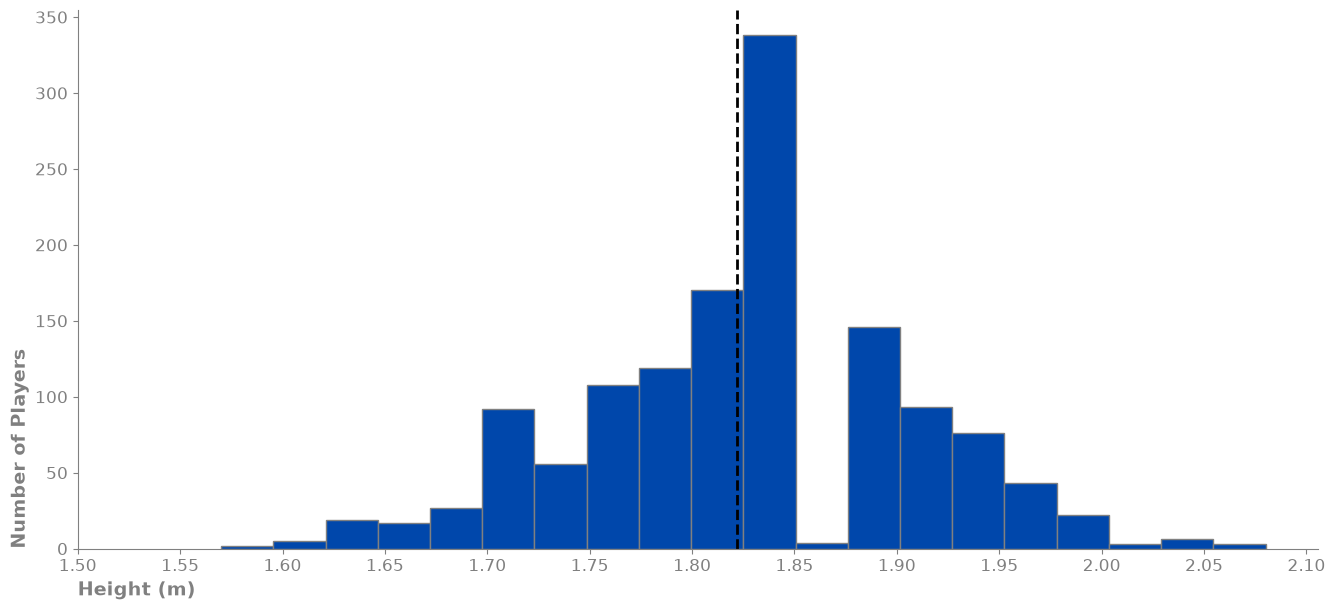

In [47]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.hist(df_unique['height'], 
         bins=20,
         color="#0047AB",
         edgecolor="gray")
ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")


ax.set_xlabel("Height (m)", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Number of Players", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.set_xticks(np.arange(1.50, 2.10, 0.05))

ax.axvline(
    average_height,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {average_height:.2f} m"
)
plt.show()